In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
!cp /content/drive/MyDrive/CCD_CLIPS_Par.zip /content/

In [ ]:
!unzip -q /content/CCD_CLIPS_Par.zip -d /content/

In [ ]:
!mv /content/content/drive/MyDrive/CCD_CLIPS_Par /content/

In [ ]:
CLIP_DIR = "/content/CCD_CLIPS_Par"

In [ ]:
import os
import numpy as np
import tensorflow as tf

from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Dense, Dropout,
    TimeDistributed, LSTM, GlobalAveragePooling2D,
    BatchNormalization
)

from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

from sklearn.utils.class_weight import compute_class_weight

In [ ]:
SEQ_LEN = 16
IMG_SIZE = 112
BATCH_SIZE = 4
EPOCHS = 25
SEED = 42

np.random.seed(SEED)
tf.random.set_seed(SEED)

In [ ]:
train_files = np.array(tf.io.gfile.glob(CLIP_DIR + "/train/*.npz"))
val_files   = np.array(tf.io.gfile.glob(CLIP_DIR + "/val/*.npz"))
test_files  = np.array(tf.io.gfile.glob(CLIP_DIR + "/test/*.npz"))

print("Train clips:", len(train_files))
print("Val clips:", len(val_files))
print("Test clips:", len(test_files))

Train clips: 9753
Val clips: 1722
Test clips: 2025


In [ ]:
def clip_file_generator(file_paths):

    for path in file_paths:

        data = np.load(path)

        clip = data["clip"]
        label = data["label"]

        yield clip.astype(np.float32), int(label)

In [ ]:
output_signature = (
    tf.TensorSpec((SEQ_LEN, IMG_SIZE, IMG_SIZE, 3), tf.float32),
    tf.TensorSpec((), tf.int32)
)

In [ ]:
train_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(train_files),
    output_signature=output_signature
).shuffle(2000).repeat().batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


val_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(val_files),
    output_signature=output_signature
).batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)


test_ds = tf.data.Dataset.from_generator(
    lambda: clip_file_generator(test_files),
    output_signature=output_signature
).batch(BATCH_SIZE)

In [ ]:
def load_labels(file_list):

    labels = []

    for f in file_list:
        data = np.load(f)
        labels.append(int(data["label"]))

    return np.array(labels)

y_train = load_labels(train_files)

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train
)

class_weight = dict(enumerate(class_weights))

print(class_weight)

{0: np.float64(0.7501153668666359), 1: np.float64(1.4995387453874538)}


In [ ]:
def build_model():

    inputs = tf.keras.Input(shape=(SEQ_LEN, IMG_SIZE, IMG_SIZE, 3))

    x = TimeDistributed(Conv2D(32,3,activation="relu"))(inputs)
    x = TimeDistributed(BatchNormalization())(x)
    x = TimeDistributed(MaxPooling2D())(x)

    x = TimeDistributed(Conv2D(64,3,activation="relu"))(x)
    x = TimeDistributed(BatchNormalization())(x)
    x = TimeDistributed(MaxPooling2D())(x)

    x = TimeDistributed(GlobalAveragePooling2D())(x)

    x = LSTM(64)(x)

    x = Dropout(0.5)(x)

    outputs = Dense(1, activation="sigmoid")(x)

    model = Model(inputs, outputs)

    model.compile(
        optimizer=Adam(3e-4),
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )

    return model


model = build_model()

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 16, 112, 112,   │             0 │
│                                 │ 3)                     │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed                │ (None, 16, 110, 110,   │           896 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_1              │ (None, 16, 110, 110,   │           128 │
│ (TimeDistributed)               │ 32)                    │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_2              │ (None, 16, 55, 55, 32) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_3              │ (None, 16, 53, 53, 64) │        18,496 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_4              │ (None, 16, 53, 53, 64) │           256 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_5              │ (None, 16, 26, 26, 64) │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ time_distributed_6              │ (None, 16, 64)         │             0 │
│ (TimeDistributed)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm (LSTM)                     │ (None, 64)             │        33,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 52,865 (206.50 KB)

 Trainable params: 52,673 (205.75 KB)

 Non-trainable params: 192 (768.00 B)

In [ ]:
steps_per_epoch = len(train_files) // BATCH_SIZE
validation_steps = len(val_files) // BATCH_SIZE

In [ ]:
checkpoint = ModelCheckpoint(
    "/content/drive/MyDrive/ccd_model.h5",
    monitor="val_loss",
    save_best_only=True
)

In [ ]:
history = model.fit(

    train_ds,

    validation_data=val_ds,

    epochs=EPOCHS,

    steps_per_epoch=steps_per_epoch,
    validation_steps=validation_steps,

    class_weight=class_weight,

    callbacks=[
        EarlyStopping(
            patience=5,
            restore_best_weights=True
        ),
        checkpoint
    ]
)

Epoch 1/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 130ms/step - accuracy: 0.7704 - loss: 0.4927

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 396s 144ms/step - accuracy: 0.7989 - loss: 0.4495 - val_accuracy: 0.9110 - val_loss: 0.2656
Epoch 2/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 125ms/step - accuracy: 0.8682 - loss: 0.3337

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 335s 137ms/step - accuracy: 0.8765 - loss: 0.3125 - val_accuracy: 0.9384 - val_loss: 0.1652
Epoch 3/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 331s 136ms/step - accuracy: 0.9126 - loss: 0.2297 - val_accuracy: 0.9360 - val_loss: 0.1798
Epoch 4/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9311 - loss: 0.1841

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9355 - loss: 0.1758 - val_accuracy: 0.9674 - val_loss: 0.0986
Epoch 5/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.9371 - loss: 0.1629 - val_accuracy: 0.9599 - val_loss: 0.1067
Epoch 6/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 328s 135ms/step - accuracy: 0.9510 - loss: 0.1338 - val_accuracy: 0.9634 - val_loss: 0.0987
Epoch 7/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 327s 134ms/step - accuracy: 0.9509 - loss: 0.1281 - val_accuracy: 0.9657 - val_loss: 0.1033
Epoch 8/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 122ms/step - accuracy: 0.9570 - loss: 0.1110

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.9547 - loss: 0.1148 - val_accuracy: 0.9721 - val_loss: 0.0769
Epoch 9/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9598 - loss: 0.1077 - val_accuracy: 0.9709 - val_loss: 0.0864
Epoch 10/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 328s 134ms/step - accuracy: 0.9615 - loss: 0.1052 - val_accuracy: 0.9669 - val_loss: 0.0889
Epoch 11/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9650 - loss: 0.0965

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9655 - loss: 0.0934 - val_accuracy: 0.9750 - val_loss: 0.0636
Epoch 12/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 328s 135ms/step - accuracy: 0.9682 - loss: 0.0886 - val_accuracy: 0.9721 - val_loss: 0.0761
Epoch 13/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 328s 135ms/step - accuracy: 0.9708 - loss: 0.0807 - val_accuracy: 0.9785 - val_loss: 0.0663
Epoch 14/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9732 - loss: 0.0726

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9739 - loss: 0.0732 - val_accuracy: 0.9808 - val_loss: 0.0526
Epoch 15/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.9706 - loss: 0.0763 - val_accuracy: 0.9727 - val_loss: 0.0698
Epoch 16/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 0s 123ms/step - accuracy: 0.9722 - loss: 0.0664

2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9742 - loss: 0.0663 - val_accuracy: 0.9785 - val_loss: 0.0505
Epoch 17/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.9773 - loss: 0.0642 - val_accuracy: 0.9750 - val_loss: 0.0712
Epoch 18/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 329s 135ms/step - accuracy: 0.9795 - loss: 0.0599 - val_accuracy: 0.9581 - val_loss: 0.1257
Epoch 19/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 328s 135ms/step - accuracy: 0.9762 - loss: 0.0601 - val_accuracy: 0.9785 - val_loss: 0.0548
Epoch 20/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 330s 135ms/step - accuracy: 0.9797 - loss: 0.0588 - val_accuracy: 0.9767 - val_loss: 0.0744
Epoch 21/25
2438/2438 ━━━━━━━━━━━━━━━━━━━━ 327s 134ms/step - accuracy: 0.9805 - loss: 0.0538 - val_accuracy: 0.9570 - val_loss: 0.1117


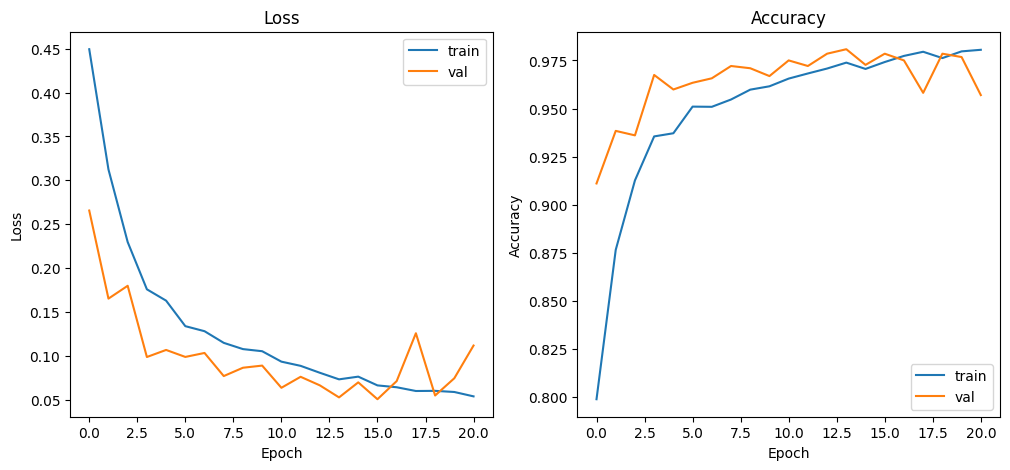

In [ ]:
import matplotlib.pyplot as plt

def plot_training(history):

    plt.figure(figsize=(12,5))

    # Loss
    plt.subplot(1,2,1)
    plt.plot(history.history["loss"], label="train")
    plt.plot(history.history["val_loss"], label="val")
    plt.title("Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()

    # Accuracy
    plt.subplot(1,2,2)
    plt.plot(history.history["accuracy"], label="train")
    plt.plot(history.history["val_accuracy"], label="val")
    plt.title("Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy")
    plt.legend()

    plt.savefig("/content/drive/MyDrive/training_curves.png")

    plt.show()

plot_training(history)

In [ ]:
model.evaluate(test_ds)

507/507 ━━━━━━━━━━━━━━━━━━━━ 37s 72ms/step - accuracy: 0.9773 - loss: 0.0648


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:164: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


[0.06479261070489883, 0.9772839546203613]

In [ ]:
y_true = []
y_pred = []

for clips, labels in test_ds:

    preds = model.predict(clips, verbose=0)

    y_true.extend(labels.numpy())
    y_pred.extend((preds > 0.5).astype(int).flatten())

from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.98      0.98      0.98      1350
           1       0.96      0.97      0.97       675

    accuracy                           0.98      2025
   macro avg       0.97      0.97      0.97      2025
weighted avg       0.98      0.98      0.98      2025



In [ ]:
from collections import defaultdict
import os
import numpy as np

In [ ]:
def video_level_evaluation(model, test_files):

    video_preds = defaultdict(list)
    video_labels = {}

    for file in test_files:

        data = np.load(file)

        clip = data["clip"]
        label = int(data["label"])

        pred = model.predict(clip[np.newaxis], verbose=0)[0][0]

        # extract video id
        name = os.path.basename(file)
        vid_id = name.split("_")[1]

        video_preds[vid_id].append(pred)
        video_labels[vid_id] = label

    correct = 0
    total = len(video_preds)

    for vid in video_preds:

        avg_pred = np.mean(video_preds[vid])

        final_pred = int(avg_pred > 0.5)

        if final_pred == video_labels[vid]:
            correct += 1

    acc = correct / total

    print("Video-level accuracy:", acc)

    return acc

In [ ]:
video_acc = video_level_evaluation(model, test_files)

Video-level accuracy: 0.9837037037037037


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns

def video_confusion_matrix(model, test_files):

    video_preds = defaultdict(list)
    video_labels = {}

    for file in test_files:

        data = np.load(file)

        clip = data["clip"]
        label = int(data["label"])

        pred = model.predict(clip[np.newaxis], verbose=0)[0][0]

        vid_id = os.path.basename(file).split("_")[1]

        video_preds[vid_id].append(pred)
        video_labels[vid_id] = label

    y_true = []
    y_pred = []

    for vid in video_preds:

        final_pred = int(np.mean(video_preds[vid]) > 0.5)

        y_true.append(video_labels[vid])
        y_pred.append(final_pred)

    cm = confusion_matrix(y_true, y_pred)

    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title("Video Level Confusion Matrix")

    plt.show()

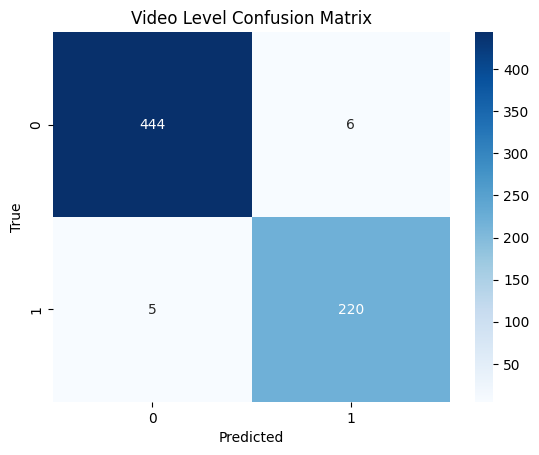

In [ ]:
video_confusion_matrix(model, test_files)

In [ ]:
model.save("/content/drive/MyDrive/ccd_cnn_lstm_model.keras")